Hello!
I'm Kenza, and this is my first academic project in AI — I'm working with time series data! I'm super excited about this journey (even if I feel a little lazy sometimes 😅).

In this project, you'll find three main parts:

    1-Understanding and visualizing the data

    2-Processing the data

    3-Applying different machine learning models for forecasting

    4-Exploring specialized Python libraries for time series analysis

# 1- Understanding Data : 


In the file "forecast...", we have forecasts for the year 2023, specifically for the months February to June (2–6). For each of these months, the data includes forecasts made on at least 10 different days. Each forecast extends from 6 hours up to 168 hours (7 days) into the future.

If you're wondering why only those months are included — it's because the project involves training on early data and testing on the following months. The project officially started in March and is scheduled to finish by June.

Let’s begin by uploading the first forecast from February to explore what the data looks like.

In [1]:
import pandas as pd
import random
random.seed(42)
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os

In [2]:
df_01_02= pd.read_csv("Forecast data 2023/Forecast_01_02_2023.csv")
target_df = pd.read_csv('Vlinder 2023/vlinder19_2023.csv')


In [3]:
target_df.rename(columns={"datetime":"time"}, inplace=True)
target_df["time"]=pd.to_datetime(target_df["time"])

In [4]:
realT= target_df.loc[( target_df["time"]< "2023-02-08 00:00:00") &  (target_df["time" ]>"2023-02-01 00:00:00") ]

# Check the shape of the filtered dataset
realT.shape


(2015, 2)

In [5]:
df_01_02.tail(10)
#df_01_02.head(10)

,time,number,latitude,longitude,cape,sp,tcw,sshf,slhf,msl,...,skt,cin,sm,st,sd,sf,tcc,tp,mx2t6,mn2t6
1440,2023-02-08 00:00:00,41,50.75,4.25,0.000000,102953.580,9.738094,6283140.5,-12131924.0,103919.195,...,270.09402,NaN,365.76100,276.42700,0.000000,2.384186e-07,67.598630,7.662772,276.10266,272.38464
1441,2023-02-08 00:00:00,42,50.75,4.25,0.052860,102800.380,7.967748,5183689.0,-10866018.0,103765.336,...,276.26150,NaN,354.27765,277.59130,0.000000,2.384186e-07,97.274030,3.235302,278.36667,276.84634
1442,2023-02-08 00:00:00,43,50.75,4.25,1.344143,102739.320,4.407448,5494132.0,-10293728.0,103717.440,...,271.13020,NaN,351.77536,275.97867,0.010529,1.231384e-02,38.602287,2.235447,275.05298,272.34787
1443,2023-02-08 00:00:00,44,50.75,4.25,0.193314,103103.625,7.894967,7008045.0,-10031826.0,104069.090,...,276.01770,NaN,359.63782,278.25540,0.000000,2.384186e-07,30.732895,4.244598,280.05017,276.89140
1444,2023-02-08 00:00:00,45,50.75,4.25,0.000000,103234.650,5.995342,8463296.0,-12013762.0,104217.520,...,268.42690,NaN,359.50528,275.38950,0.000000,2.384186e-07,0.000000,5.455376,272.69406,269.78323
1445,2023-02-08 00:00:00,46,50.75,4.25,0.000000,102982.910,4.044870,5428415.0,-10604114.0,103957.670,...,269.20404,NaN,353.55994,275.81393,0.000000,2.384186e-07,25.294363,2.349000,274.41560,270.73068
1446,2023-02-08 00:00:00,47,50.75,4.25,18.236534,102993.390,7.551997,7786168.0,-10669408.0,103967.484,...,274.47684,NaN,355.19257,276.44843,0.000371,2.384186e-07,99.456160,3.335099,276.26523,274.87256
1447,2023-02-08 00:00:00,48,50.75,4.25,0.000000,103223.880,4.331676,7692430.0,-10128790.0,104202.630,...,269.97803,NaN,363.15363,276.21610,0.000000,2.384186e-07,0.000000,6.043367,275.26700,271.36792
1448,2023-02-08 00:00:00,49,50.75,4.25,12.574524,103089.430,9.430685,6884875.5,-8263309.0,104054.670,...,273.52280,NaN,351.33408,276.91565,0.000000,2.384186e-07,96.877290,1.240986,276.60913,274.90506
1449,2023-02-08 00:00:00,50,50.75,4.25,0.000000,102891.780,5.180458,6743563.5,-10813880.0,103863.460,...,268.01147,NaN,356.19153,275.78860,0.000000,2.384186e-07,0.001526,3.518239,273.57913,269.62305


In [6]:
#time.shape
print(df_01_02.shape[0]/50)
29/8


29.0


3.625

Each file contains 50 measurements taken at 3 different forecast hours, across 8 different days.


Below is a visualization showing the forecasts over these 8 days, organized by each measurement.

You can select a value for n from 1 to 50, which corresponds to one of the 50 measurements.
we'll use n = 3 to reduce the notebook size and keep things clean.

👉 I recommend plotting all 50 measurements at first to observe that most of them follow similar patterns — they seem to correlate quite well with each other in shape and behavior.

In [7]:
n=3

29


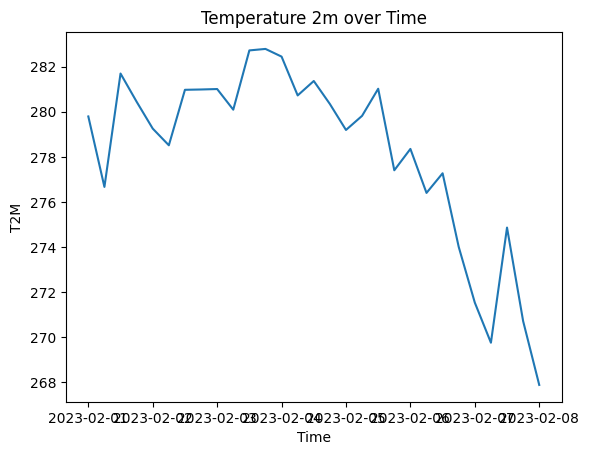

29


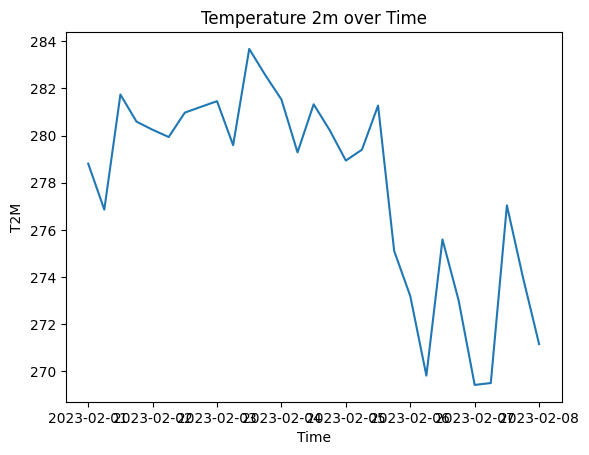

In [8]:
for i in range (1,n):
    time = pd.to_datetime(df_01_02["time"].iloc[i::50])
    t2m = pd.to_numeric(df_01_02["t2m"].iloc[i::50])
    
    print (len(time))
    plt.plot(time, t2m)
    
    plt.xlabel("Time")
    plt.ylabel("T2M")
    plt.title("Temperature 2m over Time")
    plt.show()


And this is a visualization of the actual temperature for the month of February

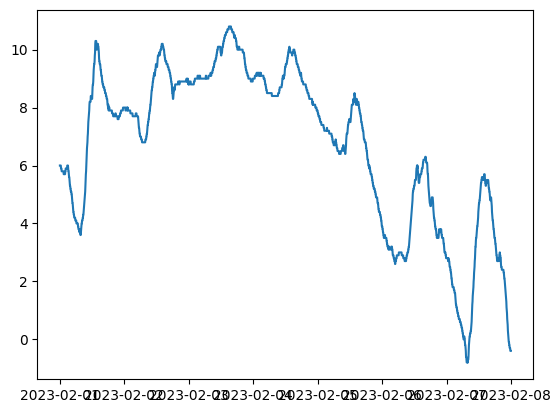

In [9]:
realT2m= pd.to_numeric(realT["temp"])
allhours=pd.to_datetime(realT["time"])
plt.plot(allhours, realT2m)

we can now upload the 28 files corresponding to different forecasting dates and merge them into one CSV file. Since the files overlap in dates, here’s how we will handle them: the closer a date is to the forecasting date, the better the forecast. Therefore, we will keep only the most recent forecast values.

We can also consider another approach. Since we are interested in weekly forecasts, for a given date X, we will retain the forecast value from the file dated X-7.

In [10]:

path = "Forecast data 2023"  # Folder containing the 28 files
all_files = glob.glob(os.path.join(path, "*.csv"))

# Load all files into a list of DataFrames
dfs = []
for file in all_files:
    df = pd.read_csv(file)
    df["forecast_date"] = "- ".join(os.path.basename(file).split("_")[1:]).split(".")[0]  # Extract the date from the filename
    df["forecast_date"] = pd.to_datetime(df["forecast_date"])  # Convert to datetime format
    dfs.append(df)

# Concatenate all files into a single DataFrame
data = pd.concat(dfs, ignore_index=True)
data["time"] = pd.to_datetime(data["time"])  # Ensure the target date column is in datetime format
# Keep only the most recent forecasts
features_df = data.sort_values(by=["time", "forecast_date"], ascending=[True, False]).drop_duplicates(subset=["time", "number"], keep="first")

# Save the results
features_df.to_csv("merged_forecast_recent.csv", index=False)

C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_15620\1586524993.py:9: UserWarning: Parsing dates in %d- %m- %Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["forecast_date"] = pd.to_datetime(df["forecast_date"])  # Convert to datetime format
C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_15620\1586524993.py:9: UserWarning: Parsing dates in %d- %m- %Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["forecast_date"] = pd.to_datetime(df["forecast_date"])  # Convert to datetime format
C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_15620\1586524993.py:9: UserWarning: Parsing dates in %d- %m- %Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["forecast_date"] = pd.to_datetime(df["forecast_date"])  # Convert to datetime format
C:\Users\CYTe

Now let's import the file that contains the target value, and process it: 

In [11]:
# Convertir en time
target_df["time"] = pd.to_datetime(target_df["time"])

# Définir les bornes de dates
start_date = pd.to_datetime("2023-02-01")
end_date = pd.to_datetime("2023-06-30")

# Filtrer la plage de dates
target_df = target_df[(target_df["time"] >= start_date) & (target_df["time"] <= end_date)]


# Mettre time en index pour resample
target_df.set_index("time", inplace=True)

# Appliquer le resample par heure et prendre la première valeur
target_df = target_df.resample("60T").first()

# Mettre time en index pour filtrer 
target_df.reset_index( inplace=True)
# Garder uniquement les lignes avec les heures 00h, 06h, 12h, 18h
target_df = target_df[
    (target_df["time"].dt.hour == 0)  | 
    (target_df["time"].dt.hour == 6)  | 
    (target_df["time"].dt.hour == 12) | 
    (target_df["time"].dt.hour == 18)
]


C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_15620\2044304247.py:16: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  target_df = target_df.resample("60T").first()


In [12]:
final_df = pd.merge(features_df, target_df, on="time", how='left')
final_df = final_df.drop(columns=["forecast_date"])

Here we go — we finally have a single file containing all the data across the selected months!
As a first step, let’s plot t2m (the forecasted temperature in Kelvin) alongside temp (the actual temperature from the Vlinder station).

This comparison is important because t2m serves as the baseline for our predictions. The ultimate goal of this project is to train a model that provides better forecasts than t2m.

In [13]:
def plot_forecast_vs_actual(df, start_date, end_date):
    """
    Plots forecasted temperature (t2m) and actual temperature (temp) for a given time period.

    Parameters:
    df (pd.DataFrame): DataFrame containing 'time', 't2m', and 'temp' columns.
    start_date (str or pd.Timestamp): Start of the period (inclusive).
    end_date (str or pd.Timestamp): End of the period (inclusive).
    """
    mask = (df["time"] >= pd.to_datetime(start_date)) & (df["time"] <= pd.to_datetime(end_date))
    period_df = df.loc[mask]

    x_time = period_df["time"]
    t2m = period_df["t2m"] - 273.15
    t2m_vlinder = period_df["temp"]

    plt.figure(figsize=(12, 6))
    plt.scatter(x_time, t2m, label="Forecasted Temperature (t2m, °C)", s=10)
    plt.scatter(x_time, t2m_vlinder, label="Vlinder Temperature (°C)", s=10, alpha=0.7)

    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Forecasted vs. Vlinder Temperature\n({start_date} to {end_date})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


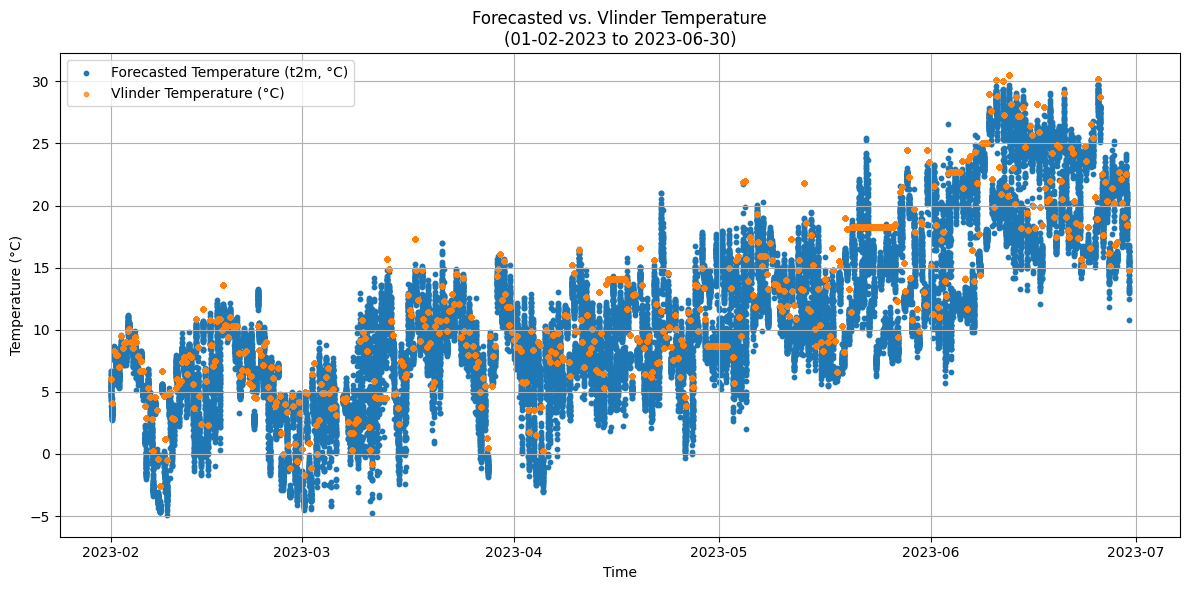

In [14]:
plot_forecast_vs_actual(final_df, "01-02-2023", end_date="2023-06-30")

Hmm... why are there so many blue points and so few orange points?  
Let's zoom in on a single month to see what's happening.

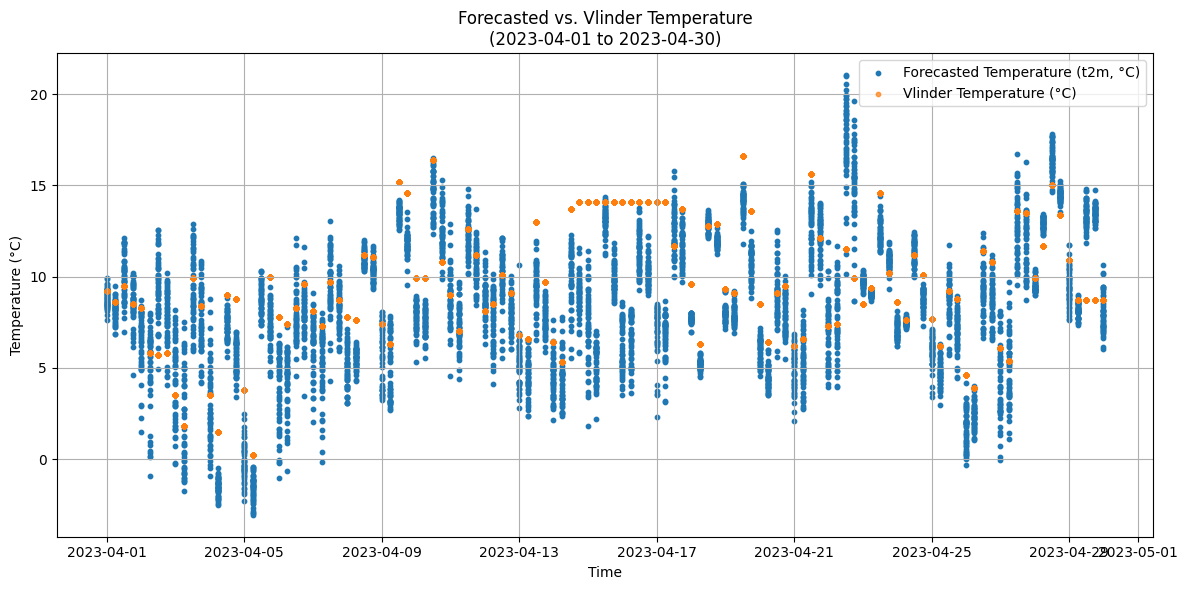

In [15]:
plot_forecast_vs_actual(final_df, "2023-04-01", end_date="2023-04-30")

Yes, of course — we have 50 predictions for every timestamp, which explains the repeated time values.
Kinda makes sense now... I'm a little "dumb" sometimes — but hey, that's how we learn!

But hey, there’s a problem with the Vlinder temperature data: how can the real temperature remain constant for two days? Look at the period between 04-13 and 04-17.  
You can even see this issue in the previous plot.


That's probably due to errors in the temperature measurements—perhaps the equipment was malfunctioning, or there were no staff available to record the temperatures, for example during holidays.
So they repeated the last measured value for all of those days.

For us, we just can't use those measurements, because they would introduce errors. We will deal with this in the Processing part .

_____________________________________

_________________________________________________________________

 # 2- Processing data :

Let's first address the errors in the real temperature measurements that we just observed.

### 2-1 Error Metrics for Vlinder Temperature Measurements

In [16]:
def find_constant_temp(df):

    """
    Find constant temperature over two timestamps  in the DataFrame.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing temperature data.
    
    Returns:
    list: List of time values where the temperature is constant.
    """

    index = 0
    temp_to_delete = []
    while index < len(final_df) - 50:
        if final_df.iloc[index]["temp"] == final_df.iloc[index + 50]["temp"]:
            temp_to_delete.append(final_df.iloc[index]["time"])
            index += 50
        else:       
            index += 50  
    
    return temp_to_delete



In [17]:
temp_to_delete = find_constant_temp(final_df)

print(temp_to_delete)

final_df = final_df.drop(final_df[final_df["time"].isin(temp_to_delete)].index)

[Timestamp('2023-02-01 18:00:00'), Timestamp('2023-02-16 18:00:00'), Timestamp('2023-02-18 18:00:00'), Timestamp('2023-02-19 00:00:00'), Timestamp('2023-02-19 06:00:00'), Timestamp('2023-03-04 00:00:00'), Timestamp('2023-03-12 00:00:00'), Timestamp('2023-03-12 06:00:00'), Timestamp('2023-03-12 12:00:00'), Timestamp('2023-03-12 18:00:00'), Timestamp('2023-03-13 00:00:00'), Timestamp('2023-03-23 12:00:00'), Timestamp('2023-04-10 00:00:00'), Timestamp('2023-04-14 18:00:00'), Timestamp('2023-04-15 00:00:00'), Timestamp('2023-04-15 06:00:00'), Timestamp('2023-04-15 12:00:00'), Timestamp('2023-04-15 18:00:00'), Timestamp('2023-04-16 00:00:00'), Timestamp('2023-04-16 06:00:00'), Timestamp('2023-04-16 12:00:00'), Timestamp('2023-04-16 18:00:00'), Timestamp('2023-04-17 00:00:00'), Timestamp('2023-04-29 06:00:00'), Timestamp('2023-04-29 12:00:00'), Timestamp('2023-04-29 18:00:00'), Timestamp('2023-04-30 00:00:00'), Timestamp('2023-04-30 06:00:00'), Timestamp('2023-04-30 12:00:00'), Timestamp('20

Now, let's verify that we have fixed the problem.

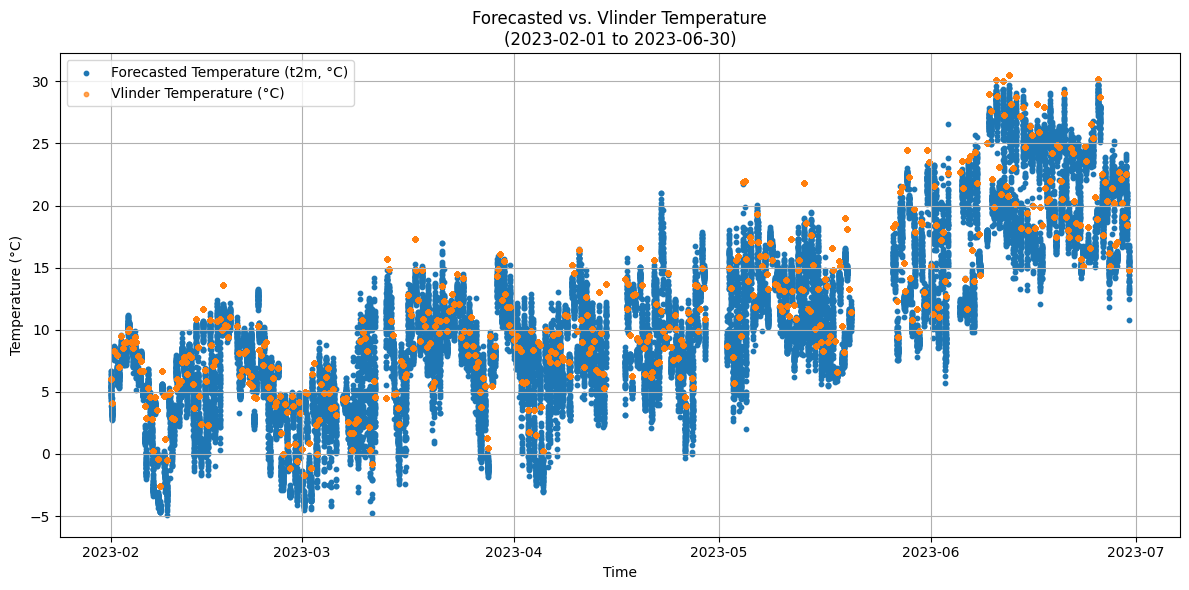

In [18]:
plot_forecast_vs_actual(final_df, "2023-02-01", end_date="2023-06-30")

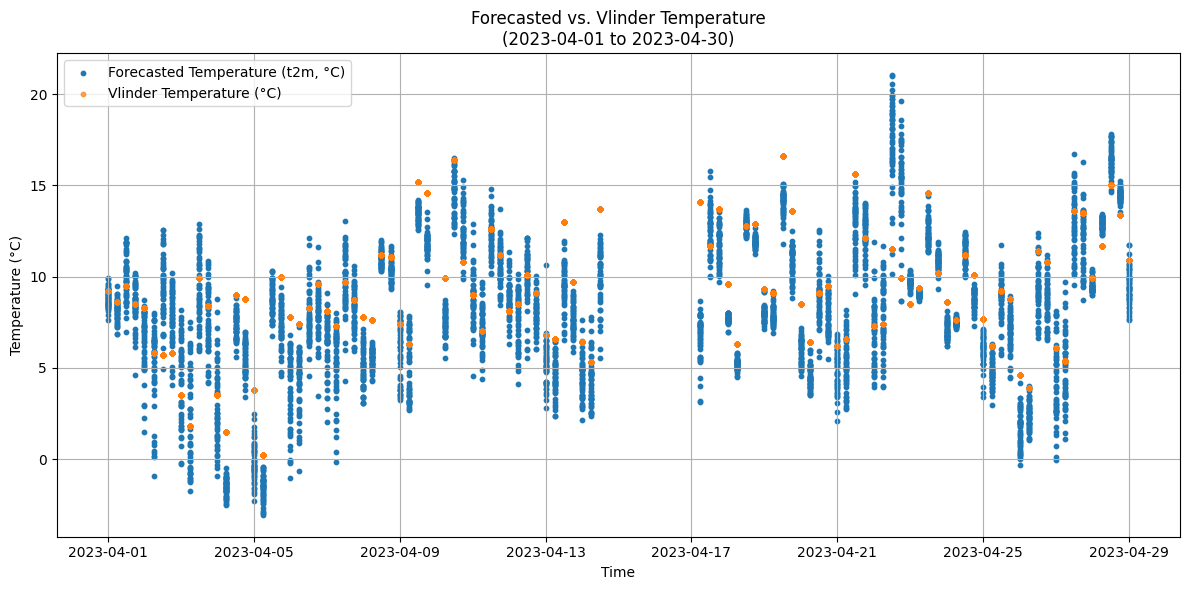

In [19]:
plot_forecast_vs_actual(final_df, "2023-04-01", end_date="2023-04-30")

Good, we don't have this problem of constant temperature anymore.

In [20]:
# S'assurer que "time" est au format datetime
final_df["time"] = pd.to_datetime(final_df["time"])

# Trouver les doublons en considérant date et heure
duplicates = final_df[final_df["time"].duplicated(keep=False)]

# Afficher les doublons
print(duplicates["time"].head(2))


0   2023-02-01
1   2023-02-01
Name: time, dtype: datetime64[ns]


### 2-2 Removing Unnecessary Columns and Handling Missing Values

with this code, we will identify the columns that have more than 60% missing values or values equal to 0, as well as the columns that have any missing values.



In [21]:
def missing_values(df):

    L = []
    LMV = []  # more than 60% null or equal to zero
    
    MV = []  # columns that have missing values
    
    i=0
    for col in df.columns:
        L.append((i, df[col].isnull().sum() / df.shape[0], (df[col] == 0).sum() / df.shape[0]))
        i += 1

    LMV = [df.columns[L[i][0]] for i in range(len(L)) if (L[i][1] >= 0.6 or L[i][2] >= 0.6)]
    MV = [df.columns[L[i][0]] for i in range(len(L)) if (L[i][1] != 0)]
   

    
    return LMV, MV


    
    

In [22]:
LMV, MV = missing_values(final_df)
print("Columns with a lot of missing values (more than 60%) , or the constant 0 in 60 % of rows :", LMV)
print("Columns that have missing values:", MV)

Columns with a lot of missing values (more than 60%) , or the constant 0 in 60 % of rows : ['cin', 'sd', 'sf']
Columns that have missing values: ['cin', 'mx2t6', 'mn2t6', 'temp']


In [23]:

# Show timestamps where 'temp' is missing in final_df
print("Timestamps with missing temp in final_df:")
print(final_df["time"][final_df["temp"].isnull()].drop_duplicates())

# Show timestamps where 'temp' is missing in target_df
print("Timestamps with missing temp in target_df:")
print(target_df["time"][target_df["temp"].isnull()])

# Check if target_df contains data for July (month 7)
print("Does target_df have data for July?")
print(target_df["time"][target_df["time"] == "2023-07-01 18:00:00"])

Timestamps with missing temp in final_df:
12550   2023-04-05 12:00:00
29700   2023-06-30 06:00:00
29750   2023-06-30 12:00:00
29800   2023-06-30 18:00:00
29850   2023-07-01 00:00:00
29900   2023-07-01 06:00:00
29950   2023-07-01 12:00:00
30000   2023-07-01 18:00:00
30050   2023-07-02 00:00:00
30100   2023-07-02 06:00:00
30150   2023-07-02 12:00:00
30200   2023-07-02 18:00:00
30250   2023-07-03 00:00:00
30300   2023-07-03 06:00:00
30350   2023-07-03 12:00:00
30400   2023-07-03 18:00:00
30450   2023-07-04 00:00:00
30500   2023-07-04 06:00:00
30550   2023-07-04 12:00:00
30600   2023-07-04 18:00:00
30650   2023-07-05 00:00:00
Name: time, dtype: datetime64[ns]
Timestamps with missing temp in target_df:
1524   2023-04-05 12:00:00
Name: time, dtype: datetime64[ns]
Does target_df have data for July?
Series([], Name: time, dtype: datetime64[ns])


From the code above, we see that some values in "temp" are missing in `final_df`. For example, the actual temperature at `'2023-04-05 12:00:00'` is missing in `final_df` because it is also missing in `target_df`.

To address this, we will simply delete these rows, since we have a lot of data and do not want to introduce bias by imputing values.

For the remaining missing values, we have two options: either remove the rows with missing data, or extend `target_df` up to `'2023-07-05 00:00:00'` to include more data.

For now, we will proceed by deleting the rows with missing values. We can revisit and improve this approach later, as having a larger training dataset could help our model learn better.


In [24]:

final_df=final_df.dropna(subset=["temp"])

For other columns that have missing values, we will delete them along with columns that have a lot of missing values. The reason is that if we try to drop rows with missing values for every column, we end up deleting up to 80% of the timestamps in some test sets. Therefore, it's more efficient to remove entire columns with excessive missing data.

In [25]:
LMV, MV = missing_values(final_df)

In [26]:
colomns_to_delete = LMV + MV
print("Columns to delete:", colomns_to_delete)
final_df = final_df.drop(columns=colomns_to_delete)

Columns to delete: ['cin', 'sd', 'sf', 'cin', 'mx2t6', 'mn2t6']


###  2-3 Normalizing data 


Before training machine learning models, it is important to normalize the data because the features have different units and scales (for example, temperature in Kelvin, pressure in hPa, etc.). Normalization ensures that each feature contributes equally to the model and helps algorithms converge faster.

In this project, we use `StandardScaler` from scikit-learn to standardize the features (mean = 0, standard deviation = 1). This is especially important for linear models and neural networks.

The normalization is applied to all numerical columns except the target variable (`temp`), which is normalized separately. This way, we can later inverse-transform the predictions to the original temperature scale for interpretation.

In [27]:
from sklearn.preprocessing import StandardScaler


def normalize_data(df, target_column=None):
    # Créer le scaler pour X
    scaler_X = StandardScaler()

    # Identifier les colonnes numériques, sauf 'number'
    numeric_columns = [col for col in df.select_dtypes(include=['float64', 'int64']).columns if col != 'number']

    # Si target_column est spécifié, traiter X et y
    if target_column is not None:
        scaler_y = StandardScaler()

        # Séparer X et y
        X = df.drop(columns=[target_column])
        y = df[[target_column]]

        # Colonnes numériques pour X, sauf 'number'
        numeric_columns_X = [col for col in X.select_dtypes(include=['float64', 'int64']).columns if col != 'number']

        # Normaliser
        X_scaled = scaler_X.fit_transform(X[numeric_columns_X])
        y_scaled = scaler_y.fit_transform(y)

        # Reconstruire DataFrame X
        X_scaled_df = X.copy()
        X_scaled_df[numeric_columns_X] = X_scaled

        return X_scaled_df, y_scaled, scaler_X, scaler_y

    else:
        # Normaliser tout le DataFrame (sauf 'number')
        df_scaled = df.copy()
        df_scaled[numeric_columns] = scaler_X.fit_transform(df[numeric_columns])

        return df_scaled, scaler_X



In [28]:
X_scaled_df, y_scaled, scaler_X, scaler_y = normalize_data(final_df, "temp")


just for curiosity, let's check if realy the scaler works .

In [29]:
# Inverse transform y_scaled to get back to the original scale
y_inverse = scaler_y.inverse_transform(y_scaled)

# Compare with the 'temp' column in final_df after dropping NaNs in 'temp'
final_df_no_nan = final_df.dropna(subset=["temp"]).reset_index(drop=True)

comparison = pd.DataFrame({
    'temp_final_df': final_df_no_nan['temp'],
    'temp_inverse': y_inverse.flatten()
})


print(comparison.head(100))
print(scaler_y.mean_, scaler_y.scale_)



    temp_final_df  temp_inverse
0             6.0           6.0
1             6.0           6.0
2             6.0           6.0
3             6.0           6.0
4             6.0           6.0
..            ...           ...
95            4.1           4.1
96            4.1           4.1
97            4.1           4.1
98            4.1           4.1
99            4.1           4.1

[100 rows x 2 columns]
[11.61226054] [6.81054534]


### 2-4 Feature Engineering

Linear regression models require all input features to be numerical. Therefore, we need to transform any non-numerical columns into numerical features before training the model.

In [30]:
def convert_time_to_int (df):
    # Ensure 'time' is in datetime forma 
    df['time'] = pd.to_datetime(df['time'])
    #Extract features from the 'time' column

    df['day'] =df['time'].dt.day   
    
    df['hour'] =df['time'].dt.hour  # Hour of the day
    df['month'] =df['time'].dt.month  # Month of the year
    df['week'] = df['time'].dt.isocalendar().week  # this coloumn is not really helpfull for prediction, but we will use it for splitting the data.
    df= df.drop(columns=["time"])
    return df
    


In [31]:

convert_time_to_int(X_scaled_df)
#X_scaled_df= X_scaled_df.drop(columns=[ "time"])
X_scaled_df.dtypes

time         datetime64[ns]
number                int64
latitude            float64
longitude           float64
cape                float64
sp                  float64
tcw                 float64
sshf                float64
slhf                float64
msl                 float64
u10                 float64
v10                 float64
t2m                 float64
d2m                 float64
ssr                 float64
str                 float64
ttr                 float64
sund                float64
skt                 float64
sm                  float64
st                  float64
tcc                 float64
tp                  float64
day                   int32
hour                  int32
month                 int32
week                 UInt32
dtype: object

## 3 - Splitting Data

We will split the data as follows: for each month, we will use the first three weeks as training data and the last week as validation data. This approach ensures that the training set includes data from all months, while the validation set tests the model on unseen time periods.

In [32]:

def get_train_val_indices(final_df):
    train_indices = []
    val_indices = []
    for month in final_df['month'].unique():
        month_df = final_df[final_df['month'] == month].copy()
        # Get unique weeks in this month, sorted
        weeks = sorted(month_df['week'].unique())
        # Assign first 3 weeks to train, last week to validation
        train_weeks = weeks[:3]
        val_weeks = weeks[3:]
        train_indices.extend(month_df[month_df['week'].isin(train_weeks)].index.tolist())
        val_indices.extend(month_df[month_df['week'].isin(val_weeks)].index.tolist())
    return train_indices, val_indices




In [33]:
train_indices, val_indices = get_train_val_indices(X_scaled_df)

# Convert indices to positional indices for iloc
train_pos = X_scaled_df.index.get_indexer(train_indices)
val_pos = X_scaled_df.index.get_indexer(val_indices)

train_df_X = X_scaled_df.iloc[train_pos].reset_index(drop=True)
val_df_X = X_scaled_df.iloc[val_pos].reset_index(drop=True)

# Fix: Convert y_scaled (numpy array) to DataFrame using positional indices
train_df_y = pd.DataFrame(y_scaled[train_pos], columns=['temp']).reset_index(drop=True)
val_df_y = pd.DataFrame(y_scaled[val_pos], columns=['temp']).reset_index(drop=True)

and here a visulazion of how we split it if it's unclear.

C:\Users\CYTech Student\AppData\Local\Temp\ipykernel_15620\937158462.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(months))


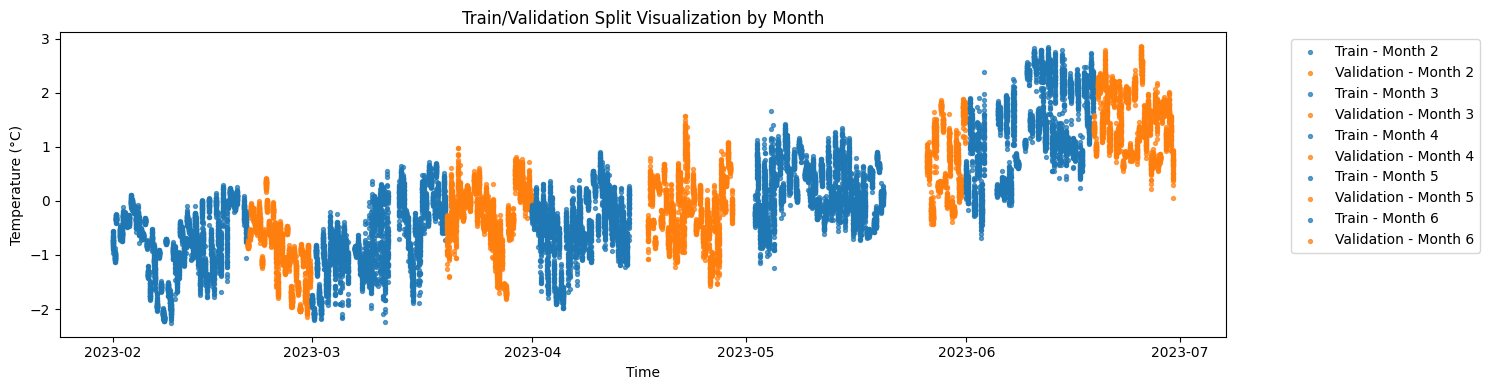

In [34]:
# Prepare a DataFrame with split labels for visualization
split_df = X_scaled_df.copy()
split_df['split'] = 'none'

# Mark splits based on indices in X_scaled_df
# Mark splits based on indices in X_scaled_df
split_df.loc[train_indices, 'split'] = 'train'
split_df.loc[val_indices, 'split'] = 'validation'

# Plot
plt.figure(figsize=(15, 4))
months = split_df['month'].unique()
colors = plt.cm.get_cmap('tab20', len(months))

for i, month in enumerate(sorted(months)):
    for split, marker in zip(['train', 'validation'], ['o', 'x']):
        mask = (split_df['split'] == split) & (split_df['month'] == month)
        plt.scatter(
            split_df.loc[mask, 'time'],
            split_df.loc[mask, 't2m'],
            label=f"{split.capitalize()} - Month {month}" if split == 'train' else f"{split.capitalize()} - Month {month}",
            s=8,
            alpha=0.7,
            color='tab:blue' if split == 'train' else 'tab:orange'
        )

plt.xlabel('Time')
plt.ylabel('Temperature (°C)')
plt.title('Train/Validation Split Visualization by Month')
# Only show legend for the first month to avoid clutter
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [35]:
#let's delete the column time, it's not needed anymore
train_df_X = train_df_X.drop(columns=["time"])
val_df_X = val_df_X.drop(columns=["time"])

now let's call all our function to final_df:

In [36]:
def processing_data(data):
    
    MV, MV = missing_values(data)
    colomns_to_delete = MV + MV
    data = data.drop(columns=colomns_to_delete)
    data = convert_time_to_int(data)
    data = normalize_data(data, "temp")[0]
    data = data.drop(columns=["time"])


    return data

# Training models:

## Linear Regression

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.feature_selection import RFECV

We will train first a linear regression model,  with selecting  the best features for prediction. We will use cross-validation and Recursive Feature Elimination with Cross-Validation (RFECV) for this task.



Recursive Feature Elimination (RFE) is a greedy optimization algorithm which aims to find the best performing feature subset. It repeatedly creates models and keeps aside the best or the worst performing feature at each iteration. It constructs the next model with the left features until all the features are exhausted. It then ranks the features based on the order of their elimination. It uses accuracy metric to rank the feature according to their importance. The RFE method takes the model to be used and the number of required features as input. It then gives the ranking to all variables, 1 being the most important. It also gives it support, True being relevant feature and False being irrelevant feature. As the name suggests, this method eliminates worst performing features on a particular model one after the other until the best subset of features are known.

In [46]:
from sklearn.metrics import mean_absolute_error


y_val_real = scaler_y.inverse_transform(val_df_y)
y_train_real = scaler_y.inverse_transform(train_df_y)


# Use Recursive Feature Elimination with Cross-Validation for feature selection
selector = RFECV(
    estimator=LinearRegression(),
    step=1,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Fit selector on training data (use DataFrame for column names)
y_train = train_df_y.values.ravel()
selector.fit(train_df_X.values, y_train)

# Get selected features
selected_features = train_df_X.columns[selector.support_]
print("Selected features:", list(selected_features))

# Transform train and validation sets to keep only selected features
X_train_selected = selector.transform(train_df_X.values)
X_val_selected = selector.transform(val_df_X.values)

# Retrain model with selected features
model_selected = LinearRegression()
model_selected.fit(X_train_selected, y_train)

# Predict and evaluate
y_pred_val_selected_scaled = model_selected.predict(X_val_selected)
y_pred_val_selected = scaler_y.inverse_transform(y_pred_val_selected_scaled.reshape(-1, 1))
y_pred_train_selected_scaled = model_selected.predict(X_train_selected)
y_pred_train_selected = scaler_y.inverse_transform(y_pred_train_selected_scaled.reshape(-1, 1))

# Calculate MAE
mae_train_selected = mean_absolute_error(y_train_real, y_pred_train_selected)
mae_selected = mean_absolute_error(y_val_real, y_pred_val_selected)

# Calculate sMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

smape_selected = smape(y_val_real, y_pred_val_selected)
smape_train_selected = smape(y_train_real, y_pred_train_selected)

# Show results in a table
results_df = pd.DataFrame({
    "Metric": ["MAE", "sMAPE"],
    "Value_validation": [mae_selected, smape_selected],
    "Value_train": [mae_train_selected, smape_train_selected]
})
print(results_df)


Selected features: ['sp', 'msl', 't2m', 'skt', 'st']
  Metric  Value_validation  Value_train
0    MAE          1.539677     1.517090
1  sMAPE         16.067386    21.287755


### Interpretation :


**MAE (Mean Absolute Error):**
- **Validation MAE = 1.54**  
  the model’s predictions are off by about **1.54°C** on the validation set.
- **Train MAE = 1.52**  
  On the training set, the average error is **1.52°C**.
- **Interpretation:**  
  The model performs similarly on both train and validation data, suggesting no major overfitting.

---

**sMAPE (Symmetric Mean Absolute Percentage Error):**
- **Validation sMAPE = 16.07%**  
  On average, your predictions are about **16% off** from the actual values (relative to the average of predicted and actual).
- **Train sMAPE = 21.29%**  
  On the training set, the average percentage error is **21.3%**.
- **Interpretation:**  
  The model is slightly more accurate on the validation set than on the training set (which is unusual, but can happen due to data splits or randomness).

---

**Summary:**  
- Your model predicts temperature with an average error of about 1.5°C and 16% relative error on unseen data.
- The similar MAE and sMAPE values for train and validation suggest your model generalizes well and is not overfitting.

In [80]:
def simple_data(df, target, real_temp):
    # Select only the needed columns
    df = df[["month", "day", "hour", "t2m", "number"]].copy()
    
    # Add the year column with default value 2023
    df['year'] = 2023

    # Create column time from columns: "year", "month", "day", "hour"
    df['time'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=df['day'], hour=df['hour']))

    # Add the target column
    df['t2m_corrected'] = target
    # Add the real temperature column
    df['t2m_real'] = real_temp
    

    # Group by time, keep average t2m for each time, and the average of t2m_corrected
    result = df.groupby('time', as_index=False)[['t2m', 't2m_corrected', 't2m_real']].mean()

    # Rename the columns
    result = result.rename(columns={'t2m': 't2m_mean', 't2m_corrected': 't2m_corrected_mean', 't2m_real': 't2m_real_first'})
    result['t2m_mean'] = result['t2m_mean']-273.15
    

    return result


In [81]:
# Only inverse transform the columns that were originally scaled
numeric_columns = [col for col in val_df_X.columns if col in scaler_X.feature_names_in_]
val_df_X_copy = val_df_X.copy()
val_df_X_copy[numeric_columns] = scaler_X.inverse_transform(val_df_X[numeric_columns])



df = simple_data(val_df_X_copy, y_pred_val_selected, y_val_real)


In [82]:
df.head(20)

,time,t2m_mean,t2m_corrected_mean,t2m_real_first
0,2023-02-20 00:00:00,4.863577,6.605230,6.3
1,2023-02-20 06:00:00,6.223298,7.408584,6.8
2,2023-02-20 12:00:00,9.383068,9.992577,8.1
3,2023-02-20 18:00:00,9.014020,9.756663,8.3
4,2023-02-21 00:00:00,7.588687,8.664734,6.7
5,2023-02-21 06:00:00,7.153254,8.250256,5.7
6,2023-02-21 12:00:00,9.112366,10.017827,6.3
7,2023-02-21 18:00:00,7.256192,8.279555,5.5
8,2023-02-22 00:00:00,2.748705,5.201182,4.6
9,2023-02-22 06:00:00,5.669925,6.808366,4.5


In [85]:
#plot the predictions
def plot_columns(df, time_col, col1, col2, col3,label1='Predicted', label2='Forecasted'):
    """
    Plot two columns over time from a DataFrame.

    Parameters:
    df (pd.DataFrame): DataFrame containing the data.
    time_col (str): Name of the time column.
    col1 (str): Name of the first column to plot.
    col2 (str): Name of the second column to plot.
    label1 (str): Label for the first column.
    label2 (str): Label for the second column.
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(14, 6))
    plt.plot(df[time_col], df[col1], label=label1, color='orange')
    plt.plot(df[time_col], df[col2], label=label2, color='blue')
    plt.plot(df[time_col], df[col3], label='Real', color='green')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.title(f'{label1} vs {label2} Over Time')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


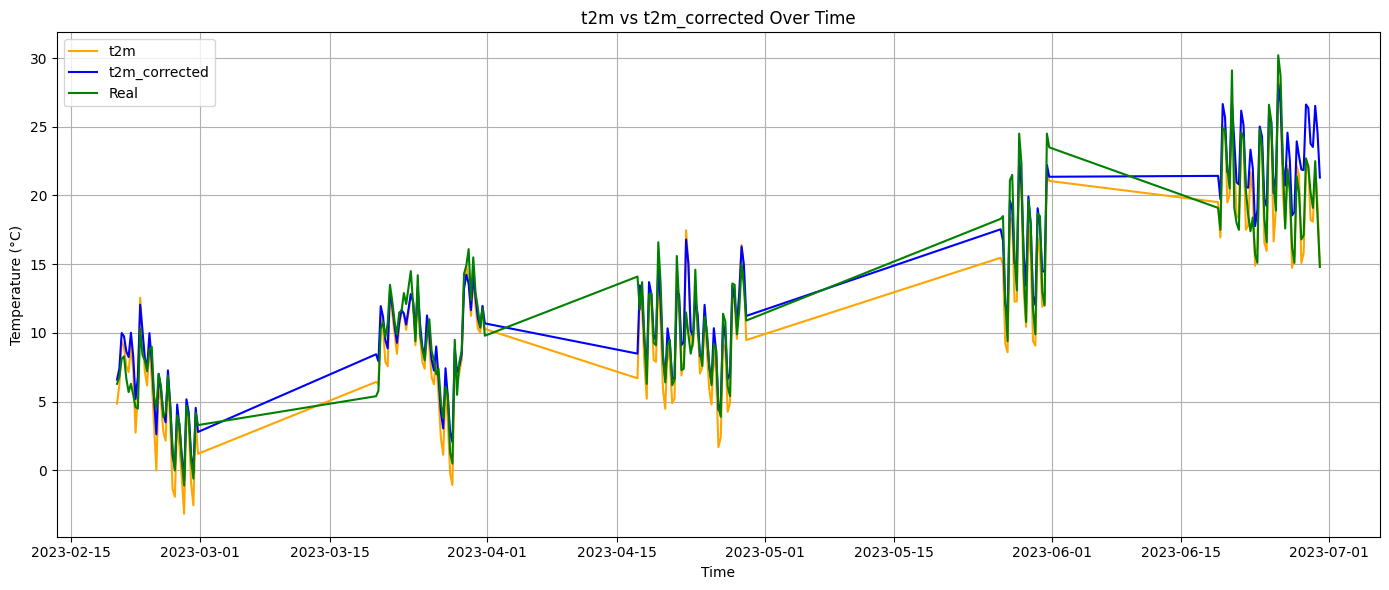

In [87]:
plot_columns(df, 'time', 't2m_mean', 't2m_corrected_mean', 't2m_real_first', label1='t2m', label2='t2m_corrected')

it looks okay, there is an improvement as the average corrected t2m by our model is closer to the real t2m than the average of the forecasted (naive) t2m.

## 2- XGBoost

In [89]:
%pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   -- ------------------------------------- 9.2/150.0 MB 47.7 MB/s eta 0:00:03
   ----- ---------------------------------- 21.5/150.0 MB 52.3 MB/s eta 0:00:03
   -------- ------------------------------- 31.2/150.0 MB 50.8 MB/s eta 0:00:03
   ----------- ---------------------------- 42.5/150.0 MB 51.0 MB/s eta 0:00:03
   --------------- ------------------------ 56.6/150.0 MB 53.8 MB/s eta 0:00:02
   ------------------ --------------------- 70.5/150.0 MB 55.5 MB/s eta 0:00:02
   ---------------------- ----------------- 82.6/150.0 MB 56.7 MB/s eta 0:00:02
   ------------------------- -------------- 96.7/150.0 MB 57.2 MB/s eta 0:00:01
   ---------------------------- ---------- 109.8/150.0 MB 58.0 MB/s eta 0:00:01
   -------------------------------- ------ 123.5/150.0 MB 58.4 MB/s eta 0:00:01
   ----------------------------------- --- 137.1/150.0 MB 59.6 MB/s eta 0:00:01
   --------------------------------------  149.9/1


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [93]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best XGBoost parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Train MAE: 1.171
Validation MAE: 1.589
Train sMAPE: 18.30%
Validation sMAPE: 19.83%


c:\Users\CYTech Student\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


ExecutableNotFound: failed to execute WindowsPath('dot'), make sure the Graphviz executables are on your systems' PATH

<Figure size 2000x800 with 0 Axes>

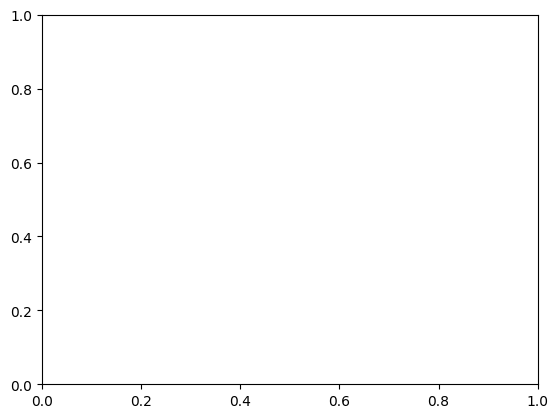

In [95]:


from xgboost import XGBRegressor, plot_tree
from sklearn.metrics import mean_absolute_error
import numpy as np

import matplotlib.pyplot as plt

# Prepare data (use all features)
X_train = train_df_X.values
y_train = train_df_y.values.ravel()
X_val = val_df_X.values
y_val = val_df_y.values.ravel()

# Define parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42, n_jobs=-1)
grid_search = GridSearchCV(xgb, param_grid, cv=3, scoring='neg_mean_absolute_error', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

# Predict and inverse transform
y_pred_train_scaled = best_xgb.predict(X_train)
y_pred_val_scaled = best_xgb.predict(X_val)
y_pred_train = scaler_y.inverse_transform(y_pred_train_scaled.reshape(-1, 1))
y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled.reshape(-1, 1))
y_train_real = scaler_y.inverse_transform(y_train.reshape(-1, 1))
y_val_real = scaler_y.inverse_transform(y_val.reshape(-1, 1))

# Metrics
def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

mae_train = mean_absolute_error(y_train_real, y_pred_train)
mae_val = mean_absolute_error(y_val_real, y_pred_val)
smape_train = smape(y_train_real, y_pred_train)
smape_val = smape(y_val_real, y_pred_val)

print("Best XGBoost parameters:", grid_search.best_params_)
print(f"Train MAE: {mae_train:.3f}")
print(f"Validation MAE: {mae_val:.3f}")
print(f"Train sMAPE: {smape_train:.2f}%")
print(f"Validation sMAPE: {smape_val:.2f}%")

# Visualize the first tree
plt.figure(figsize=(20, 8))
plot_tree(best_xgb, num_trees=0, rankdir='LR')
plt.title("First Tree of the Best XGBoost Model")
plt.show()

In [ ]:
pls trainan Xgboost model on the same data as linear regression, start with using all the features , not the selected ones, and tune the hyperparameters using a cross validation approach., measure the metrics "MAEn sMAPE", on both training and validation data, visulise the tree at the end

_____________________________________________


let's split our data, to training data, validation data and test data. 
to make sure that we have in our training data a sample for all months data, we will split the data based on "the number of measures", that means the thre of plits will have the same number of dates, but the number of measurs of each will be diffrent.

In [39]:
import random
random.seed(42)

# Générer tous les nombres de 1 à 50
all_numbers = list(range(1, 51))


# 1. Prendre 20% aléatoires (soit 10 nombres)
set_1 = set(random.sample(all_numbers, 10))

# 2. Prendre 20% d'autres nombres aléatoires, ceux déjà dans set1
set_2 = set(random.sample(list(set(all_numbers) - set_1 ), 10))

# 3. Le reste
set_3 = set(all_numbers) - set_1 - set_2

# Afficher les résultats
print("Set 1 (20% random):", sorted(set_1))
print("Set 2 (20% others", sorted(set_2))
print("Set 3 (remaining):", sorted(set_3))


Set 1 (20% random): [2, 6, 7, 8, 9, 15, 16, 18, 35, 41]
Set 2 (20% others [3, 4, 11, 22, 23, 26, 37, 43, 47, 48]
Set 3 (remaining): [1, 5, 10, 12, 13, 14, 17, 19, 20, 21, 24, 25, 27, 28, 29, 30, 31, 32, 33, 34, 36, 38, 39, 40, 42, 44, 45, 46, 49, 50]


In [40]:
# Assurons-nous que y_scaled est bien un DataFrame
y_scaled_df = pd.DataFrame(y_scaled, columns=['temp'])  # Ou mets le vrai nom de ta colonne cible ici

# Collect all subsets into a list
X_test_subsets = [
    X_scaled_df.iloc[i-1::50]  
    for i in set_1
]

Y_test_subsets = [
    y_scaled_df.iloc[i-1::50]  
    for i in set_1
]

# Combine everything into a single DataFrame
X_test_df = pd.concat(X_test_subsets, ignore_index=True)
y_test_df = pd.concat(Y_test_subsets, ignore_index=True)



X_validation_subsets = [
    X_scaled_df.iloc[i-1::50]  
    for i in set_2
]

Y_validation_subsets = [
    y_scaled_df.iloc[i-1::50]  
    for i in set_2
]


X_validation_df = pd.concat(X_validation_subsets, ignore_index=True)
y_validation_df = pd.concat(Y_validation_subsets, ignore_index=True)






# Collect all subsets into a list
X_train_subsets = [
    X_scaled_df.iloc[i-1::50]  
    for i in set_3
]

Y_train_subsets = [
    y_scaled_df.iloc[i-1::50]  
    for i in set_3
]

# Combine everything into a single DataFrame
X_train_df = pd.concat(X_train_subsets, ignore_index=True)
y_train_df = pd.concat(Y_train_subsets, ignore_index=True)


    

finally, let's start traing our model .

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score



In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Convertir les DataFrames en numpy arrays (si pas déjà fait)
X_train = X_train_df.values
y_train = y_train_df.values

X_val = X_validation_df.values
y_val = y_validation_df.values

# 2. Créer et entraîner le modèle
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Faire des prédictions sur le set de validation
y_pred_val_scaled = model.predict(X_val)

# 4. Inverser la normalisation (température prédite)
y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled)
y_val_real = scaler_y.inverse_transform(y_val)

# 5. Évaluer la performance
rmse = np.sqrt(mean_squared_error(y_val_real, y_pred_val))
print(f"RMSE sur le set de validation : {rmse:.2f}")

# 6. (Optionnel) Afficher quelques résultats
for i in range(5):
    print(f"Prédit: {y_pred_val[i][0]:.2f} °C — Réel: {y_val_real[i][0]:.2f} °C")


TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [ ]:
type(X_train)

numpy.ndarray

now let's predict the temperature weekely :


In [ ]:

def cleaning_data(data):

    MV,CD = missing_values(data)
    data=data.dropna(subset=MV)
        
    columns_to_drop= data[list( set(CD) & set(['cin', 'sd', 'sf']))]
    data=data.drop(columns=columns_to_drop)
    convert_time_to_int(data)

    for col in data.columns :
        if col not in X_scaled_df.columns : 
            print (col)
            data=data.drop(columns=col)
    
    scaled_data, _ = normalize_data(data)

    return scaled_data
    

In [ ]:
data_03 = pd.read_csv("weekly data/forecast_2025_04_05.csv")
time = data_03["time"]
missing_values(data_03)



(['cin', 'sd', 'sf', 'tp'], ['cin', 'mx2t6', 'mn2t6'])

In [ ]:
scaler_x = StandardScaler()
data_03 = cleaning_data(data_03)
data_03.shape

time
sd
sf
mx2t6
mn2t6


(2, 25)

In [ ]:
# 3. predict the temperature of "2025_03_02"
y_pred_03_scaled = model.predict(data_03.values)

# 4. Inverser la normalisation (température prédite)
y_pred_03 = scaler_y.inverse_transform(y_pred_03_scaled)

# 6. (Optionnel) Afficher quelques résultats
for i in range(2):
    print(f"Prédit: {y_pred_03[i][0]:.2f} °C ")


Prédit: 17.37 °C 
Prédit: 5.98 °C 


In [ ]:
data_03['t2m_predict']= y_pred_03
data_03["time"]= time
data_03.to_csv("weekly Data\predict_2025_04_05.csv", index=True)


In [ ]:
"""
data_03["t2m_predict"]
data_03["time"]
"""
time

0       2025-04-05 00:00:00
1       2025-04-05 00:00:00
2       2025-04-05 00:00:00
3       2025-04-05 00:00:00
4       2025-04-05 00:00:00
               ...         
1445    2025-04-12 00:00:00
1446    2025-04-12 00:00:00
1447    2025-04-12 00:00:00
1448    2025-04-12 00:00:00
1449    2025-04-12 00:00:00
Name: time, Length: 1450, dtype: object

the plan : 

1-change the splits of my data: 
data lakeage : changing the split of y data : 1-first weak for each month to avoid correlation between training and test sit.
#Data snooping is a form of statistical bias manipulating data or analysis to artificially get statistically significant results: https://datascience.stanford.edu/news/data-snooping

3- Visualise the vlinder data over all the concerned period, with points .

2-think about what are the best date columns are more important.

3- train 2 other distinct model

4-I need to tune hyper parameters of my model.

5- use cross validation .

6- select the best features.

7- think about taking the average of predictions, than calculate the metrics

#For time-series forecasting (relevant to our blog), metrics like Mean Absolute Scaled Error (MASE) or Symmetric Mean Absolute Percentage Error (sMAPE) are useful.

